In [133]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [134]:
df = pd.read_csv("loan-train.csv")

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# Handle Missing values

In [136]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns

In [137]:
numerical_cols.size + categorical_cols.size

13

In [138]:
# Fill missing values

from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

category_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = category_imp.fit_transform(df[categorical_cols])

In [139]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,146.412162,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.000000,360.0,1.0,Urban,Y


# EDA - Exploratory Data Analysis

Text(0.5, 1.0, 'Is loan approved or not')

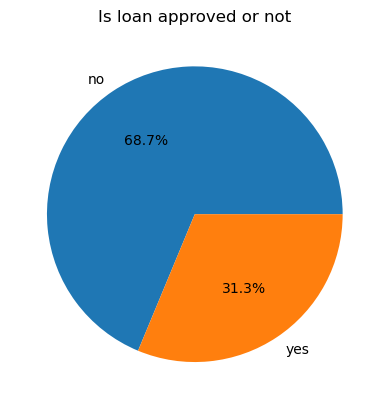

In [140]:
# How balanced our classes are ?

classes_count = df["Loan_Status"].value_counts()

plt.pie(classes_count, labels=["no", "yes"], autopct="%1.1f%%")
plt.title("Is loan approved or not")

[Text(0, 0, '502'), Text(0, 0, '112')]

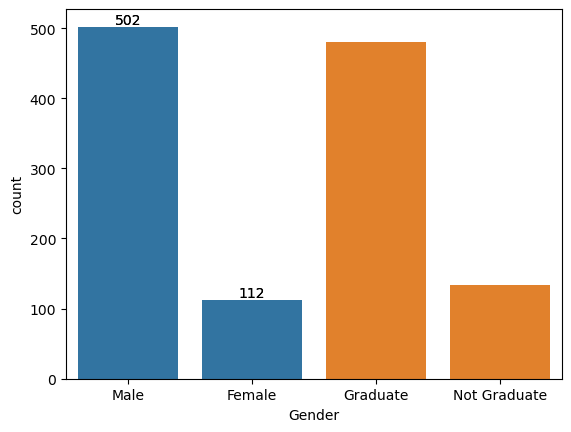

In [141]:
# Analyze categories

gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

education_cnt = df["Education"].value_counts()
ax = sns.barplot(education_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

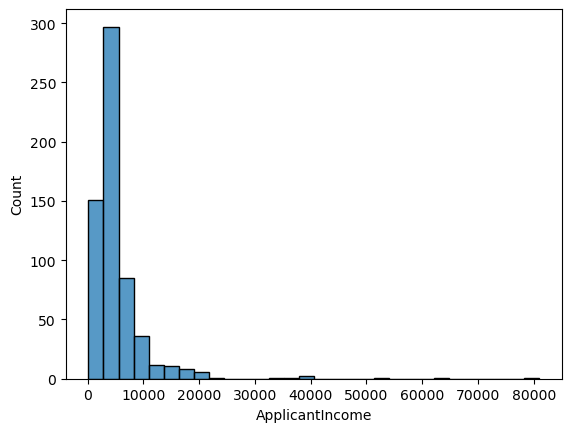

In [142]:
# Analyze  income

sns.histplot(
    data=df,
    x="ApplicantIncome",
    bins=30
)

<Axes: xlabel='CoapplicantIncome', ylabel='Count'>

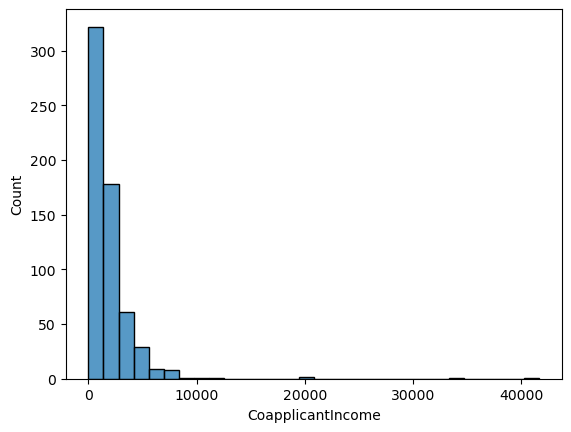

In [143]:
sns.histplot(
    data=df,
    x="CoapplicantIncome",
    bins=30
)

<Axes: xlabel='Loan_Status', ylabel='ApplicantIncome'>

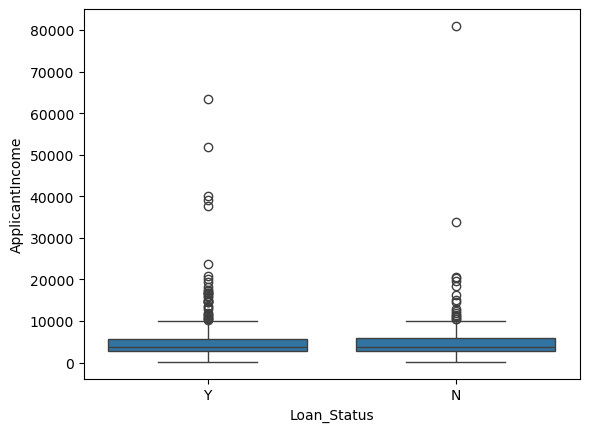

In [144]:
# outliers - boxplots

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="ApplicantIncome"
)

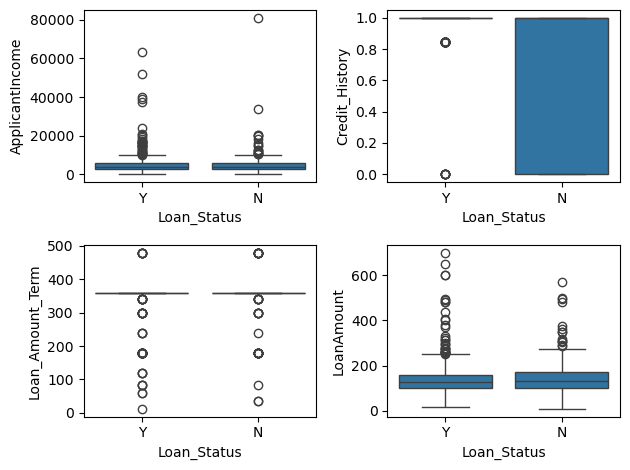

In [145]:
fig, axes = plt.subplots(2, 2)

sns.boxplot(ax=axes[0, 0], data=df, x="Loan_Status", y="ApplicantIncome")
sns.boxplot(ax=axes[0, 1], data=df, x="Loan_Status", y="Credit_History")
sns.boxplot(ax=axes[1, 0], data=df, x="Loan_Status", y="Loan_Amount_Term")
sns.boxplot(ax=axes[1, 1], data=df, x="Loan_Status", y="LoanAmount")

plt.tight_layout()

<Axes: xlabel='Credit_History', ylabel='Count'>

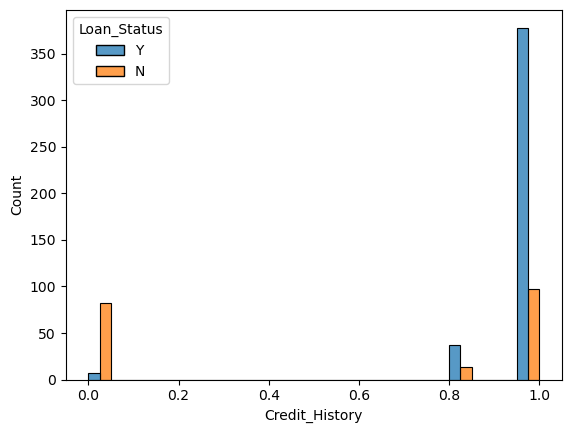

In [146]:
# Credit score with Loan approved

sns.histplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

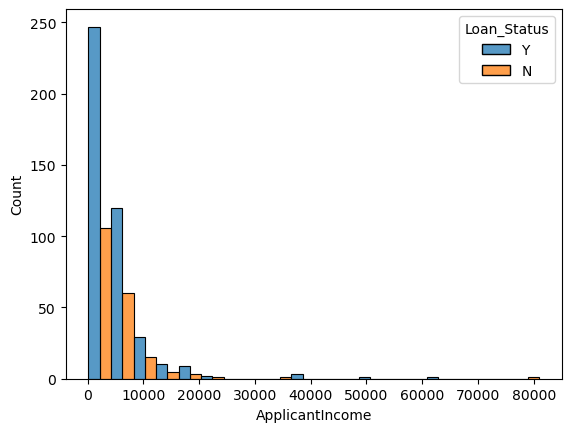

In [147]:
sns.histplot(
    data=df,
    x="ApplicantIncome",
    hue="Loan_Status",
    bins=20,
    multiple="dodge"
)

In [148]:
# Remove Loan id

df = df.drop("Loan_ID", axis=1)

# Encoding

In [1]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Label encoder

le = LabelEncoder()
df["Education"] = le.fit_transform(df["Education"])
df["Loan_Status"] = le.fit_transform(df["Loan_Status"])

NameError: name 'df' is not defined

In [ ]:
df.head()

In [151]:
# One hot encoder

cols = ["Gender", "Married", "Self_Employed", "Property_Area"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [152]:
df.head()

,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,0,5849.0,0.0,146.412162,360.0,1.0,1,1.0,0.0,0.0,0.0,1.0
1,1,0,4583.0,1508.0,128.000000,360.0,1.0,0,1.0,1.0,0.0,0.0,0.0
2,0,0,3000.0,0.0,66.000000,360.0,1.0,1,1.0,1.0,1.0,0.0,1.0
3,0,1,2583.0,2358.0,120.000000,360.0,1.0,1,1.0,1.0,0.0,0.0,1.0
4,0,0,6000.0,0.0,141.000000,360.0,1.0,1,1.0,0.0,0.0,0.0,1.0


# Correlation Heatmap

In [153]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

In [154]:
corr_matrix

,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
Education,1.000000,-0.140760,-0.062290,-0.166998,-0.077242,-0.077936,-0.085884,0.045364,0.012304,-0.010383,-0.039410,-0.034279
ApplicantIncome,-0.140760,1.000000,-0.116605,0.565620,-0.045242,-0.014477,-0.004710,0.058809,0.051708,0.127180,-0.014246,-0.000598
CoapplicantIncome,-0.062290,-0.116605,1.000000,0.187828,-0.059675,-0.001665,-0.059187,0.082912,0.075948,-0.016100,-0.027044,0.022776
LoanAmount,-0.166998,0.565620,0.187828,1.000000,0.038801,-0.007738,-0.036416,0.107930,0.147141,0.115260,-0.008273,-0.033220
Loan_Amount_Term,-0.077242,-0.045242,-0.059675,0.038801,1.000000,0.001395,-0.020974,-0.073567,-0.100863,-0.033943,0.061365,-0.096683
Credit_History,-0.077936,-0.014477,-0.001665,-0.007738,0.001395,1.000000,0.540483,0.012819,0.005852,-0.002260,0.040757,-0.022621
Loan_Status,-0.085884,-0.004710,-0.059187,-0.036416,-0.020974,0.540483,1.000000,0.017987,0.091478,-0.003700,0.136540,-0.043621
Gender_Male,0.045364,0.058809,0.082912,0.107930,-0.073567,0.012819,0.017987,1.000000,0.364569,-0.000525,-0.108623,0.034530
Married_Yes,0.012304,0.051708,0.075948,0.147141,-0.100863,0.005852,0.091478,0.364569,1.000000,0.004489,0.005845,0.000546
Self_Employed_Yes,-0.010383,0.127180,-0.016100,0.115260,-0.033943,-0.002260,-0.003700,-0.000525,0.004489,1.000000,0.008710,-0.030338


In [155]:
num_cols.corr()["Loan_Status"].sort_values(ascending=False)

Loan_Status                1.000000
Credit_History             0.540483
Property_Area_Semiurban    0.136540
Married_Yes                0.091478
Gender_Male                0.017987
Self_Employed_Yes         -0.003700
ApplicantIncome           -0.004710
Loan_Amount_Term          -0.020974
LoanAmount                -0.036416
Property_Area_Urban       -0.043621
CoapplicantIncome         -0.059187
Education                 -0.085884
Name: Loan_Status, dtype: float64

<Axes: >

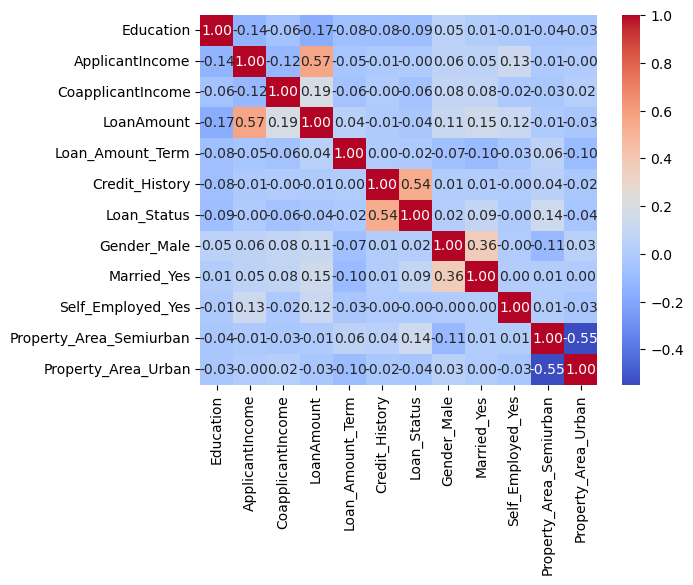

In [156]:
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Train_Test_Split + Feature Scaling

In [2]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

NameError: name 'df' is not defined

In [ ]:
X.head()

In [159]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [174]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: '3+'

In [163]:
X_train_scaled

array([[-0.53417255,  0.18066742,  1.349992  , ..., -0.08644072,
        -0.69203733,  0.89033098],
       [-0.53417255,  0.38543027, -0.20474803, ..., -0.16654082,
        -0.69203733,  0.95556856],
       [-0.53417255,  0.00583145,  0.71185244, ..., -0.07743873,
        -0.69203733,  0.81752736],
       ...,
       [-0.53417255, -0.52812706, -1.37660433, ..., -0.1614603 ,
         1.44500876, -1.09475057],
       [-0.53417255, -0.52812706, -0.02592784, ...,  0.10445221,
        -0.69203733, -1.09475057],
       [-0.53417255, -0.52812706, -0.02592784, ...,  0.3554214 ,
         1.44500876, -1.09475057]], shape=(491, 12))

# Train & Evaluate Models

In [164]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation

print("Logistic Regression")
print("precision score: ", precision_score(y_test, y_pred)*100)
print("accuracy score: ", accuracy_score(y_test, y_pred)*100)
print("recall score: ", recall_score(y_test, y_pred)*100)
print("F1 score: ", f1_score(y_test, y_pred)*100)
print(" confusion matrix ", confusion_matrix(y_test, y_pred))

Logistic Regression
precision score:  75.96153846153845
accuracy score:  78.86178861788618
recall score:  98.75
F1 score:  85.86956521739131
 confusion matrix  [[18 25]
 [ 1 79]]


In [165]:
# KNN  

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score, f1_score


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation

print("KNN model")
print("precision score: ", precision_score(y_test, y_pred)*100)
print("accuracy score: ", accuracy_score(y_test, y_pred)*100)
print("recall score: ", recall_score(y_test, y_pred)*100)
print("F1 score: ", f1_score(y_test, y_pred)*100)
print(" confusion matrix ", confusion_matrix(y_test, y_pred))

KNN model
precision score:  75.72815533980582
accuracy score:  78.04878048780488
recall score:  97.5
F1 score:  85.24590163934425
 confusion matrix  [[18 25]
 [ 2 78]]


In [166]:
#  Naive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score, f1_score

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation

print("Naive bayes model")
print("precision score: ", precision_score(y_test, y_pred)*100)
print("accuracy score: ", accuracy_score(y_test, y_pred)*100)
print("recall score: ", recall_score(y_test, y_pred)*100)
print("F1 score: ", f1_score(y_test, y_pred)*100)
print(" confusion matrix ", confusion_matrix(y_test, y_pred))

Naive bayes model
precision score:  75.72815533980582
accuracy score:  78.04878048780488
recall score:  97.5
F1 score:  85.24590163934425
 confusion matrix  [[18 25]
 [ 2 78]]


# Best model  on the basis of precision score ==> Logistic Regression

# Feature Engineering

In [167]:
# Add or transform features

df["ApplicantIncome_sq"] = df["ApplicantIncome"] ** 2
df["Property_Area_Urban_sq"] = df["Property_Area_Urban"] ** 2
#df["CoApplicantIncome_log"] = np.log1p(df["CoapplicantIncome"])

X = df.drop(columns=["Loan_Status", "ApplicantIncome", "Property_Area_Urban"])
y = df["Loan_Status"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: '3+'

In [168]:
X_train.head()

,Dependents,Education,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Self_Employed_Yes,Property_Area_Semiurban,ApplicantIncome_sq,Property_Area_Urban_sq
83,0,0,2250.0,265.0,360.0,0.842199,1.0,1.0,0.0,1.0,36000000.0,0.0
90,0,0,2900.0,131.0,360.0,1.000000,1.0,1.0,0.0,1.0,8749764.0,0.0
227,2,0,1695.0,210.0,360.0,1.000000,1.0,1.0,0.0,1.0,39062500.0,0.0
482,0,0,3150.0,128.0,360.0,1.000000,1.0,1.0,0.0,1.0,4338889.0,0.0
464,0,0,0.0,98.0,360.0,0.000000,1.0,0.0,0.0,1.0,17355556.0,0.0


In [169]:
# Logistic regression after feature engineering

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation

print("Logistic Regression")
print("precision score: ", precision_score(y_test, y_pred)*100)
print("accuracy score: ", accuracy_score(y_test, y_pred)*100)
print("recall score: ", recall_score(y_test, y_pred)*100)
print("F1 score: ", f1_score(y_test, y_pred)*100)
print(" confusion matrix ", confusion_matrix(y_test, y_pred))

Logistic Regression
precision score:  75.96153846153845
accuracy score:  78.86178861788618
recall score:  98.75
F1 score:  85.86956521739131
 confusion matrix  [[18 25]
 [ 1 79]]


In [170]:
#  Naive Bayes after feature engineering

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score, f1_score

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation

print("Naive bayes model")
print("precision score: ", precision_score(y_test, y_pred)*100)
print("accuracy score: ", accuracy_score(y_test, y_pred)*100)
print("recall score: ", recall_score(y_test, y_pred)*100)
print("F1 score: ", f1_score(y_test, y_pred)*100)
print(" confusion matrix ", confusion_matrix(y_test, y_pred))

Naive bayes model
precision score:  75.72815533980582
accuracy score:  78.04878048780488
recall score:  97.5
F1 score:  85.24590163934425
 confusion matrix  [[18 25]
 [ 2 78]]


In [171]:
# KNN after feature engineering

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score, f1_score


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation

print("KNN model")
print("precision score: ", precision_score(y_test, y_pred)*100)
print("accuracy score: ", accuracy_score(y_test, y_pred)*100)
print("recall score: ", recall_score(y_test, y_pred)*100)
print("F1 score: ", f1_score(y_test, y_pred)*100)
print(" confusion matrix ", confusion_matrix(y_test, y_pred))

KNN model
precision score:  75.72815533980582
accuracy score:  78.04878048780488
recall score:  97.5
F1 score:  85.24590163934425
 confusion matrix  [[18 25]
 [ 2 78]]
